In [9]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
VIB Reproducibility Analysis
Runs multiple independent VIB training runs to assess reproducibility
"""

import torch
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from sklearn.preprocessing import StandardScaler
import os
import dill as pickle
import fns_plotting_scripts as fns_plot
import fns_NN

# Close all existing figures
plt.close('all')

# ============= CONFIGURATION =============
LATENT_DIM = 2
EPOCHS = 800
LEARNING_RATE = 1e-3
HIDDEN_DIM = 32
BETA = 0.01
N_LAYERS = 2
TRAIN_SIZE = 3  # Number of colonies to use for training

# Reproducibility settings
MODE_TRAIN = True  # Set to False to load existing reproducibility results
N_REPRODUCIBILITY_RUNS = 10  # Number of independent training runs

# Training strategy
TRAINING_STRATEGY = 'single_condition'  # 'all_conditions' or 'single_condition'
TRAINING_CONDITION = 'B50'  # Only used if TRAINING_STRATEGY = 'single_condition'

# Data paths
directory = 'data_expt_20_scaled_norm_bgsub'
subdirectory_data = directory + '/data'
OUTPUT_DIR = directory + '/fig2_2_VIB_reproducibility'
VIB_DATA_DIR = OUTPUT_DIR + '/data'
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(VIB_DATA_DIR, exist_ok=True)

# Conditions to analyze
conditions = ['B10', 'B50', 'B200']

In [20]:
import torch

# ============= GPU ACCELERATION SETUP =============
# Check for Apple Silicon GPU availability
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("Using Apple Silicon GPU (MPS)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("Using NVIDIA GPU (CUDA)")
else:
    device = torch.device("cpu")
    print("Using CPU")

print("="*60)
print("VIB REPRODUCIBILITY ANALYSIS")
print("="*60)
print(f"Number of independent runs: {N_REPRODUCIBILITY_RUNS}")
print(f"Training strategy: {TRAINING_STRATEGY}")
print(f"Device: {device}")
if TRAINING_STRATEGY == 'single_condition':
    print(f"Training condition: {TRAINING_CONDITION}")

# ============= LOAD DATA =============

print("\n" + "="*60)
print("LOADING DATA FROM MULTIPLE CONDITIONS")
print("="*60)

all_data = {}
for cond in conditions:
    print(f"\nLoading condition: {cond}")
    f = open(subdirectory_data + '/data_' + cond + ".pickle", 'rb')
    data = pickle.load(f)
    f.close()
    
    # Use colony-based train/test split
    feature = data.signals[:,:,:-1]
    target = data.genes
    
    (feat_train, feat_test, tar_train, tar_test,
     metricdist_train, metricdist_test, markers_train, markers_test) = fns_NN.test_train_split_colonies(
        data, feature, target, train_size=TRAIN_SIZE
    )
    
    # Combine train and test for visualization
    feature_clean = np.vstack([feat_train, feat_test])
    target_clean = np.vstack([tar_train, tar_test])
    markers_clean = np.concatenate([markers_train, markers_test])
    split_labels = np.array(['train'] * len(feat_train) + ['test'] * len(feat_test))
    
    markers_clean, fate_names = fns_plot.return_fates(target_clean, data.gene_names, thresh=1)
    
    all_data[cond] = {
        'X': feature_clean,
        'Y': target_clean,
        'markers': markers_clean,
        'split_labels': split_labels,
        'signal_names': data.signal_names[:-1], # -1 to remove pAKT
        'gene_names': data.gene_names,
        'fate_names': fate_names
    }

# Get dimension info
INPUT_NAMES = all_data[conditions[0]]['signal_names']
OUTPUT_NAMES = all_data[conditions[0]]['gene_names']
MARKER_NAMES = all_data[conditions[0]]['fate_names']
N_DIM_INPUT = all_data[conditions[0]]['X'].shape[1]
N_DIM_OUTPUT = all_data[conditions[0]]['Y'].shape[1]

# ============= COMBINE DATA =============

# Concatenate all conditions
X_list = []
Y_list = []
marker_list = []
condition_labels = []
split_labels_list = []

for cond in conditions:
    X_list.append(all_data[cond]['X'])
    Y_list.append(all_data[cond]['Y'])
    marker_list.append(all_data[cond]['markers'])
    split_labels_list.append(all_data[cond]['split_labels'])
    condition_labels.extend([cond] * all_data[cond]['X'].shape[0])

X_raw = np.vstack(X_list)
Y_raw = np.vstack(Y_list)
marker_labels = np.concatenate(marker_list)
condition_labels = np.array(condition_labels)
split_labels = np.concatenate(split_labels_list)

# Remove junk data (marker = 6)
if 6 in marker_labels:
    keep_mask = marker_labels != 6
    X_raw = X_raw[keep_mask]
    Y_raw = Y_raw[keep_mask]
    marker_labels = marker_labels[keep_mask]
    condition_labels = condition_labels[keep_mask]
    split_labels = split_labels[keep_mask]

print(f"\nTotal samples: {len(marker_labels)}")

# ============= PREPARE DATA FOR TRAINING =============

if TRAINING_STRATEGY == 'single_condition':
    train_mask = (condition_labels == TRAINING_CONDITION) & (split_labels == 'train')
    test_mask = (condition_labels == TRAINING_CONDITION) & (split_labels == 'test')
else:  # all_conditions
    train_mask = split_labels == 'train'
    test_mask = split_labels == 'test'

X_train_raw = X_raw[train_mask]
Y_train_raw = Y_raw[train_mask]

# Standardize
scaler_X = StandardScaler()
scaler_Y = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train_raw)
Y_train_scaled = scaler_Y.fit_transform(Y_train_raw)
X_train = torch.FloatTensor(X_train_scaled).to(device)  # Move to GPU
Y_train = torch.FloatTensor(Y_train_scaled).to(device)  # Move to GPU

# Full dataset for visualization
X_scaled = scaler_X.transform(X_raw)
X_full = torch.FloatTensor(X_scaled).to(device)  # Move to GPU

print(f"Training samples: {X_train_scaled.shape[0]}")

# ============= RUN REPRODUCIBILITY ANALYSIS =============

repro_data_path = os.path.join(VIB_DATA_DIR, 'reproducibility_results.pickle')

if MODE_TRAIN:
    print("\n" + "="*60)
    print("RUNNING REPRODUCIBILITY ANALYSIS")
    print("="*60)
    
    # Store results from all runs
    all_latent_codes = []
    all_predicted_markers = []
    
    for run_idx in range(N_REPRODUCIBILITY_RUNS):
        print(f"\n--- Run {run_idx + 1}/{N_REPRODUCIBILITY_RUNS} ---")
        
        # Create new model with random initialization
        vib_repro = fns_NN.FlexibleVIB(
            input_dim=N_DIM_INPUT,
            output_dim=N_DIM_OUTPUT,
            latent_dim=LATENT_DIM,
            hidden_dim=HIDDEN_DIM,
            n_layers=N_LAYERS,
            encoder_type='nonlinear',
            decoder_type='nonlinear'
        ).to(device)  # Move model to GPU
        
        # Train model
        _ = fns_NN.train_model(
            vib_repro, X_train, Y_train,
            is_vae=False,
            epochs=EPOCHS,
            lr=LEARNING_RATE,
            beta=BETA,
            verbose=(run_idx == 0),  # Only verbose for first run
            print_every=200
        )

        # Get latent codes and predictions
        vib_repro.eval()
        with torch.no_grad():
            latent_mu_repro, _ = vib_repro.encode(X_full)
            latent_codes_repro = latent_mu_repro.cpu().numpy()  # Move back to CPU for numpy
            Y_pred_repro = vib_repro.decode(latent_mu_repro).cpu().numpy()  # Move back to CPU
        
        # Calculate predicted markers
        Y_pred_original_repro = scaler_Y.inverse_transform(Y_pred_repro)
        markers_pred_repro, _ = fns_plot.return_fates(Y_pred_original_repro, OUTPUT_NAMES, thresh=1)
        
        all_latent_codes.append(latent_codes_repro)
        all_predicted_markers.append(markers_pred_repro)
    
    # Save reproducibility results
    print(f"\nSaving reproducibility results to {repro_data_path}...")
    repro_data = {
        'all_latent_codes': all_latent_codes,
        'all_predicted_markers': all_predicted_markers,
        'N_REPRODUCIBILITY_RUNS': N_REPRODUCIBILITY_RUNS,
        'marker_labels': marker_labels,
        'condition_labels': condition_labels,
        'MARKER_NAMES': MARKER_NAMES,
        'conditions': conditions
    }
    with open(repro_data_path, 'wb') as f:
        pickle.dump(repro_data, f)
    
    print("✓ All reproducibility runs complete and saved")

else:
    print("\n" + "="*60)
    print("LOADING REPRODUCIBILITY RESULTS")
    print("="*60)
    
    # Load reproducibility results
    with open(repro_data_path, 'rb') as f:
        repro_data = pickle.load(f)
    
    all_latent_codes = repro_data['all_latent_codes']
    all_predicted_markers = repro_data['all_predicted_markers']
    marker_labels = repro_data['marker_labels']
    condition_labels = repro_data['condition_labels']
    MARKER_NAMES = repro_data['MARKER_NAMES']
    
    # Verify number of runs matches
    if len(all_latent_codes) != N_REPRODUCIBILITY_RUNS:
        print(f"Warning: Loaded {len(all_latent_codes)} runs but N_REPRODUCIBILITY_RUNS={N_REPRODUCIBILITY_RUNS}")
        print(f"Using {len(all_latent_codes)} runs from saved data")
        N_REPRODUCIBILITY_RUNS = len(all_latent_codes)
    
    print("✓ Reproducibility results loaded")

Using Apple Silicon GPU (MPS)
VIB REPRODUCIBILITY ANALYSIS
Number of independent runs: 10
Training strategy: single_condition
Device: mps
Training condition: B50

LOADING DATA FROM MULTIPLE CONDITIONS

Loading condition: B10

Loading condition: B50

Loading condition: B200

Total samples: 82345
Training samples: 15037

RUNNING REPRODUCIBILITY ANALYSIS

--- Run 1/10 ---
  Epoch 200/800, Loss: 0.5564, Recon: 0.5215, KL: 3.4816
  Epoch 400/800, Loss: 0.5182, Recon: 0.4827, KL: 3.5501
  Epoch 600/800, Loss: 0.5014, Recon: 0.4659, KL: 3.5518
  Epoch 800/800, Loss: 0.4899, Recon: 0.4543, KL: 3.5650

--- Run 2/10 ---

--- Run 3/10 ---

--- Run 4/10 ---

--- Run 5/10 ---

--- Run 6/10 ---

--- Run 7/10 ---

--- Run 8/10 ---

--- Run 9/10 ---

--- Run 10/10 ---

Saving reproducibility results to data_expt_20_scaled_norm_bgsub/fig2_2_VIB_reproducibility/data/reproducibility_results.pickle...
✓ All reproducibility runs complete and saved



GENERATING REPRODUCIBILITY VISUALIZATION


/var/folders/6d/flcpr9z93kd6kfzpy3dfv0tc0000gn/T/ipykernel_90106/4047391229.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab10')


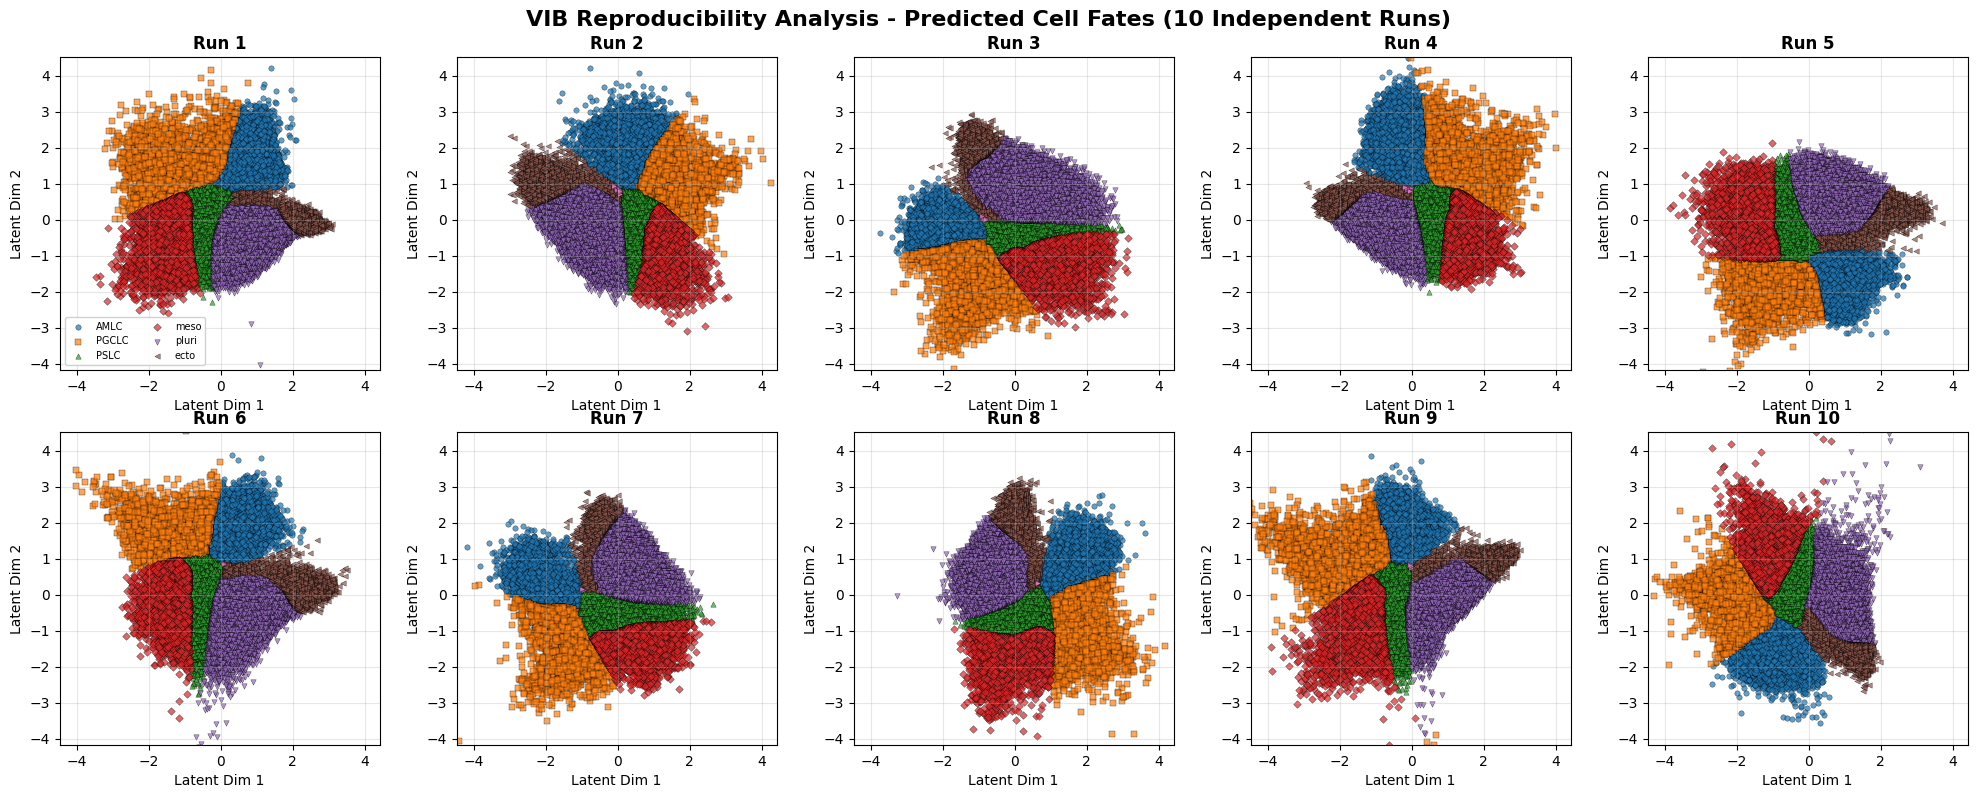

✓ Saved: reproducibility_analysis.png

REPRODUCIBILITY ANALYSIS COMPLETE
Results saved to: data_expt_20_scaled_norm_bgsub/fig2_2_VIB_reproducibility



In [11]:
# ============= VISUALIZATION =============

print("\n" + "="*60)
print("GENERATING REPRODUCIBILITY VISUALIZATION")
print("="*60)

# Define colors for markers
cmap = mpl.cm.get_cmap('tab10')
marker_colors = cmap(list(np.linspace(0, 1, 10)))
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Calculate global axis limits based on all runs
all_x_coords = np.concatenate([lc[:, 0] for lc in all_latent_codes])
all_y_coords = np.concatenate([lc[:, 1] for lc in all_latent_codes])
x_min, x_max = np.percentile(all_x_coords, [0.1, 99.9])
y_min, y_max = np.percentile(all_y_coords, [0.1, 99.9])

# Expand limits
x_range = x_max - x_min
y_range = y_max - y_min
x_min_expanded = x_min - 0.25 * x_range
x_max_expanded = x_max + 0.25 * x_range
y_min_expanded = y_min - 0.25 * y_range
y_max_expanded = y_max + 0.25 * y_range

# Calculate grid layout
n_cols = min(5, N_REPRODUCIBILITY_RUNS)
n_rows = int(np.ceil(N_REPRODUCIBILITY_RUNS / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
if N_REPRODUCIBILITY_RUNS == 1:
    axes = np.array([axes])
axes = axes.flatten()

for run_idx in range(N_REPRODUCIBILITY_RUNS):
    ax = axes[run_idx]
    
    latent_run = all_latent_codes[run_idx]
    markers_run = all_predicted_markers[run_idx]
    
    # Check if markers are valid
    unique_markers_run = np.unique(markers_run)
    has_valid_markers_run = not (len(unique_markers_run) == 1 and np.isnan(unique_markers_run[0]))
    
    if has_valid_markers_run:
        unique_markers_run = unique_markers_run[~np.isnan(unique_markers_run)]
        
        for idx, marker_val in enumerate(unique_markers_run):
            mask = markers_run == marker_val
            if np.sum(mask) > 0:
                if int(marker_val) < len(MARKER_NAMES):
                    label = MARKER_NAMES[int(marker_val)]
                else:
                    label = f"Fate {int(marker_val)}"
                
                ax.scatter(latent_run[mask, 0], latent_run[mask, 1],
                          c=[marker_colors[idx % 10]], 
                          marker=marker_styles[idx % len(marker_styles)],
                          s=15, alpha=0.7, label=label,
                          edgecolors='black', linewidth=0.3)
    else:
        ax.scatter(latent_run[:, 0], latent_run[:, 1],
                  c='blue', s=15, alpha=0.7, edgecolors='black', linewidth=0.3)
    
    ax.set_xlabel('Latent Dim 1', fontsize=10)
    ax.set_ylabel('Latent Dim 2', fontsize=10)
    ax.set_title(f'Run {run_idx + 1}', fontsize=12, fontweight='bold')
    ax.set_xlim([x_min_expanded, x_max_expanded])
    ax.set_ylim([y_min_expanded, y_max_expanded])
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    if run_idx == 0 and has_valid_markers_run:
        ax.legend(fontsize=7, loc='best', framealpha=0.9, ncol=2)

# Hide unused subplots
for idx in range(N_REPRODUCIBILITY_RUNS, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'VIB Reproducibility Analysis - Predicted Cell Fates ({N_REPRODUCIBILITY_RUNS} Independent Runs)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reproducibility_analysis.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: reproducibility_analysis.png")

print("\n" + "="*60)
print("REPRODUCIBILITY ANALYSIS COMPLETE")
print("="*60)
print(f"Results saved to: {OUTPUT_DIR}\n")


GENERATING REPRODUCIBILITY VISUALIZATION


/var/folders/6d/flcpr9z93kd6kfzpy3dfv0tc0000gn/T/ipykernel_90106/1826678358.py:8: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap('tab10')


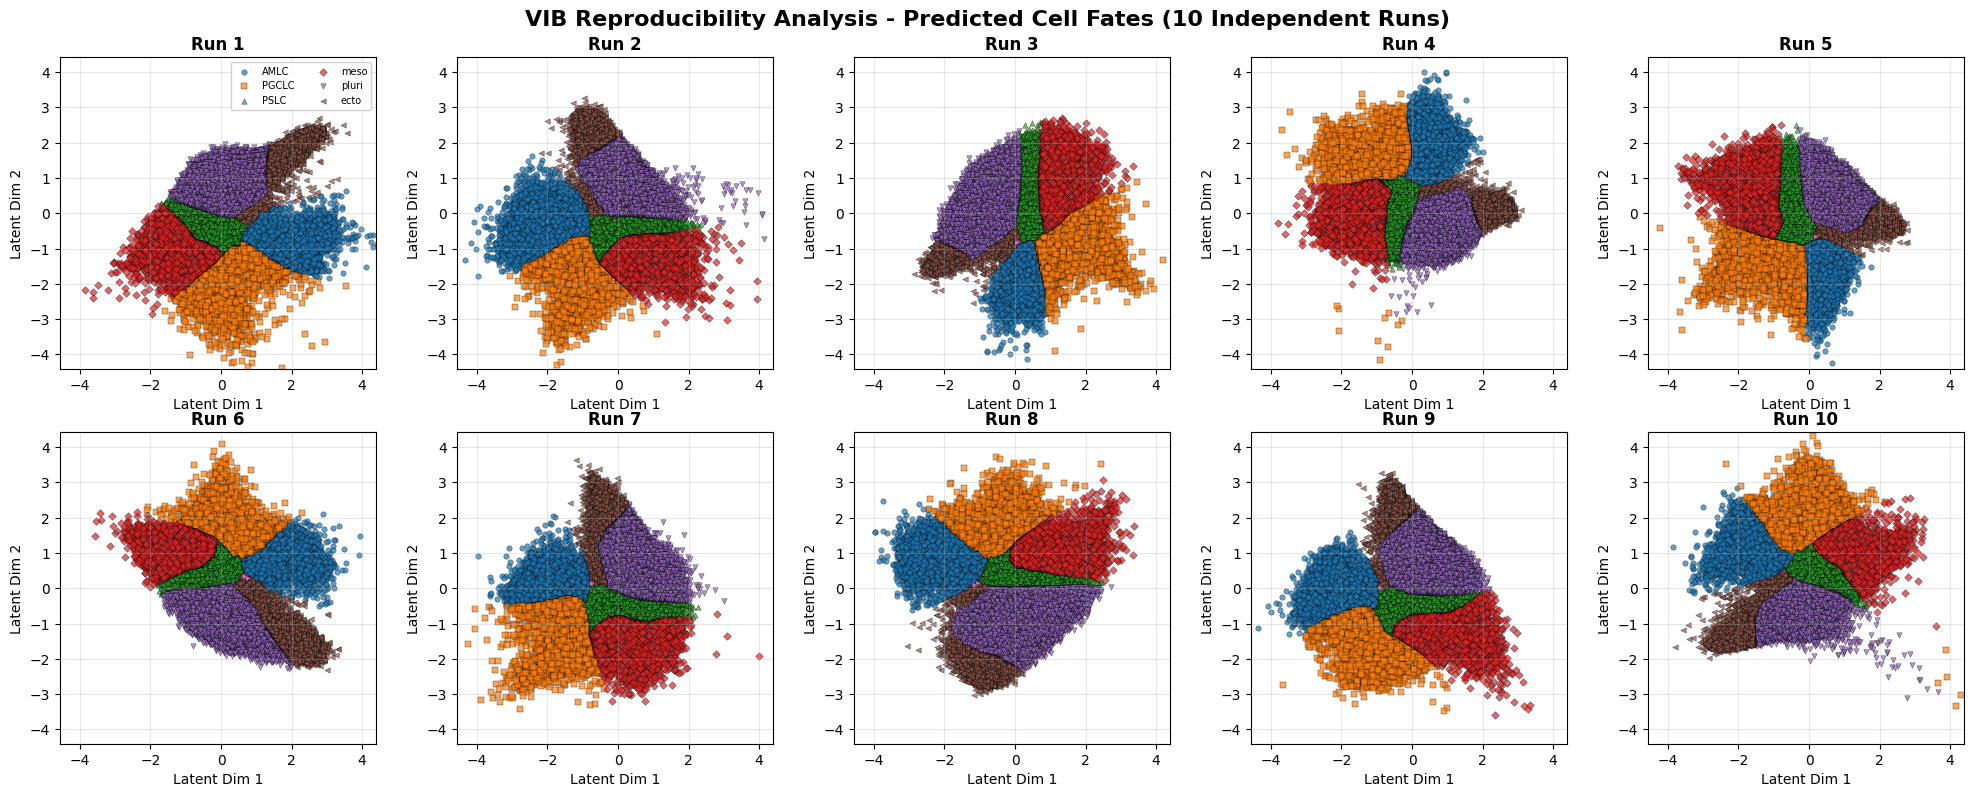

✓ Saved: reproducibility_analysis.png

REPRODUCIBILITY ANALYSIS COMPLETE
Results saved to: data_expt_20_scaled_norm_bgsub/fig2_2_VIB_reproducibility



In [22]:
# ============= VISUALIZATION =============

print("\n" + "="*60)
print("GENERATING REPRODUCIBILITY VISUALIZATION")
print("="*60)

# Define colors for markers
cmap = mpl.cm.get_cmap('tab10')
marker_colors = cmap(list(np.linspace(0, 1, 10)))
marker_styles = ['o', 's', '^', 'D', 'v', '<', '>', 'p', '*', 'h']

# Calculate global axis limits based on all runs
all_x_coords = np.concatenate([lc[:, 0] for lc in all_latent_codes])
all_y_coords = np.concatenate([lc[:, 1] for lc in all_latent_codes])
x_min, x_max = np.percentile(all_x_coords, [0.1, 99.9])
y_min, y_max = np.percentile(all_y_coords, [0.1, 99.9])

# Expand limits
x_range = x_max - x_min
y_range = y_max - y_min
x_min_expanded = x_min - 0.25 * x_range
x_max_expanded = x_max + 0.25 * x_range
y_min_expanded = y_min - 0.25 * y_range
y_max_expanded = y_max + 0.25 * y_range

# Calculate grid layout
n_cols = min(5, N_REPRODUCIBILITY_RUNS)
n_rows = int(np.ceil(N_REPRODUCIBILITY_RUNS / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4*n_cols, 4*n_rows))
if N_REPRODUCIBILITY_RUNS == 1:
    axes = np.array([axes])
axes = axes.flatten()

for run_idx in range(N_REPRODUCIBILITY_RUNS):
    ax = axes[run_idx]
    
    latent_run = all_latent_codes[run_idx]
    markers_run = all_predicted_markers[run_idx]
    
    # Check if markers are valid
    unique_markers_run = np.unique(markers_run)
    has_valid_markers_run = not (len(unique_markers_run) == 1 and np.isnan(unique_markers_run[0]))
    
    if has_valid_markers_run:
        unique_markers_run = unique_markers_run[~np.isnan(unique_markers_run)]
        
        for idx, marker_val in enumerate(unique_markers_run):
            mask = markers_run == marker_val
            if np.sum(mask) > 0:
                if int(marker_val) < len(MARKER_NAMES):
                    label = MARKER_NAMES[int(marker_val)]
                else:
                    label = f"Fate {int(marker_val)}"
                
                ax.scatter(latent_run[mask, 0], latent_run[mask, 1],
                          c=[marker_colors[idx % 10]], 
                          marker=marker_styles[idx % len(marker_styles)],
                          s=15, alpha=0.7, label=label,
                          edgecolors='black', linewidth=0.3)
    else:
        ax.scatter(latent_run[:, 0], latent_run[:, 1],
                  c='blue', s=15, alpha=0.7, edgecolors='black', linewidth=0.3)
    
    ax.set_xlabel('Latent Dim 1', fontsize=10)
    ax.set_ylabel('Latent Dim 2', fontsize=10)
    ax.set_title(f'Run {run_idx + 1}', fontsize=12, fontweight='bold')
    ax.set_xlim([x_min_expanded, x_max_expanded])
    ax.set_ylim([y_min_expanded, y_max_expanded])
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal')
    
    if run_idx == 0 and has_valid_markers_run:
        ax.legend(fontsize=7, loc='best', framealpha=0.9, ncol=2)

# Hide unused subplots
for idx in range(N_REPRODUCIBILITY_RUNS, len(axes)):
    axes[idx].axis('off')

plt.suptitle(f'VIB Reproducibility Analysis - Predicted Cell Fates ({N_REPRODUCIBILITY_RUNS} Independent Runs)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'reproducibility_analysis_noAKT.png'), dpi=150, bbox_inches='tight')
plt.show()
print("✓ Saved: reproducibility_analysis.png")

print("\n" + "="*60)
print("REPRODUCIBILITY ANALYSIS COMPLETE")
print("="*60)
print(f"Results saved to: {OUTPUT_DIR}\n")